In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import platform
import os
import glob

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

mpl.rcParams['axes.unicode_minus'] = False

file_path = "C:\python_course\통계학/2024.csv"
whole_df = pd.read_csv(file_path,encoding='cp949', parse_dates=["계약일","취소일"])

<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\j2h09\AppData\Local\Temp\ipykernel_26724\3913793156.py:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  file_path = "C:\python_course\통계학/2024.csv"
C:\Users\j2h09\AppData\Local\Temp\ipykernel_26724\3913793156.py:26: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  whole_df = pd.read_csv(file_path,encoding='cp949', parse_dates=["계약일","취소일"])


In [2]:
from sklearn.preprocessing import StandardScaler

In [3]:
df = whole_df[['건물명','자치구코드', '자치구명', '법정동코드', '법정동명','층','건물용도','물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)','계약일']]
df.columns = ['건물명','자치구코드', '자치구명', '법정동코드', '법정동명','층','건물용도','물건금액', '건물면적', '토지면적','계약일']

In [ ]:
df.dropna(inplace = True)
# 원본에 dropna 한 것 바로 적용

C:\Users\j2h09\AppData\Local\Temp\ipykernel_26724\1791587065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace = True)


In [12]:
df.describe()

,자치구코드,법정동코드,층,물건금액,건물면적,토지면적,계약일
count,69886.00,69886.00,69886.00,69886.00,69886.00,69886.00,69886
mean,11458.72,10928.45,7.75,84213.44,62.23,14.01,2024-05-30 05:08:49.651146240
min,11110.00,10100.00,-2.00,2600.00,8.48,0.00,2022-07-08 00:00:00
25%,11305.00,10200.00,3.00,30000.00,40.20,0.00,2024-03-31 00:00:00
50%,11470.00,10600.00,6.00,62000.00,59.85,0.00,2024-06-13 00:00:00
75%,11620.00,11000.00,11.00,110000.00,84.77,25.40,2024-07-27 00:00:00
max,11740.00,18700.00,68.00,2200000.00,288.40,30822.00,2024-10-14 00:00:00
std,177.45,1199.78,6.30,80280.77,29.74,118.68,NaN


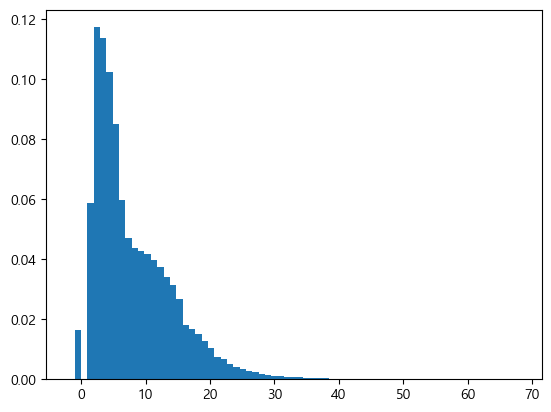

In [ ]:
plt.hist(df['층'], bins = 71, density = True) 
# Y축을 빈도수 대신 확률밀도로 변환, 막대들의 넓이를 합하면 1이 된다.
plt.show()

In [15]:
df['층'].value_counts(normalize=True).sort_values(ascending=False)
# 고유값들의 빈도수 대신 상대적인 비율 계산하여 반환함.

층
2.00    0.12
3.00    0.11
4.00    0.10
5.00    0.08
6.00    0.06
        ... 
63.00   0.00
60.00   0.00
52.00   0.00
67.00   0.00
64.00   0.00
Name: proportion, Length: 61, dtype: float64

2024년 거래된 매물 중에서 2층이 차지하는 비율은 약 12%에 달한다.

2024년에 거래된 매물 중에서 아무거나 1개를 선택했을 때, 2층일 확률이 12%이다. 

## 표준화

In [ ]:
multiplex_house_df = df.loc[df['건물용도']=='연립다세대']
# 건물용도가 연립다세대인 행만 남겨 데이터프레임 만듦.

In [ ]:
multiplex_house_df.describe()
# multiplex_house_df의 데이터 분포를 살펴보자.

,자치구코드,법정동코드,층,물건금액,건물면적,토지면적,계약일
count,21183.00,21183.00,21183.00,21183.00,21183.00,21183.00,21183
mean,11443.34,10850.47,3.03,35977.08,45.19,29.49,2024-05-18 17:43:36.003398912
min,11110.00,10100.00,-2.00,2600.00,8.48,3.00,2022-07-08 00:00:00
25%,11305.00,10200.00,2.00,22300.00,29.93,19.00,2024-03-15 00:00:00
50%,11440.00,10500.00,3.00,30000.00,43.02,25.00,2024-05-23 00:00:00
75%,11590.00,10900.00,4.00,40500.00,55.43,32.00,2024-07-26 00:00:00
max,11740.00,18700.00,18.00,1085000.00,288.40,30822.00,2024-10-14 00:00:00
std,168.33,1156.70,1.88,32384.91,19.72,212.72,NaN


In [18]:
# IQR 방식의 이상치 제거
area_data = multiplex_house_df['토지면적'].values
q_1 = np.percentile(area_data, q=25)
q_3 = np.percentile(area_data,q=75)
iqr = q_3 - q_1

In [19]:
lower_whisker = q_1 - 1.5 * iqr 
upper_whisker = q_3 + 1.5 * iqr

In [20]:
# 이상치 제거한 데이터 나오게끔 해보기! 

multiplex_house_df_cleaned = multiplex_house_df.loc[multiplex_house_df['토지면적'].between(lower_whisker,upper_whisker)]
# multiplex_house_df_cleaned = multiplex_house_df.loc[(multiplex_house_df['토지면적']>=lower_whisker)&(multiplex_house_df['토지면적']<=upper_whisker)]

In [ ]:
multiplex_house_df_cleaned
# 이상치 제거한 데이터 살펴보기

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일
0,성원빌라(86-125),11380,은평구,10200,녹번동,4.00,연립다세대,16400,53.07,25.00,2024-10-14
1,팔팔빌라,11500,강서구,10300,화곡동,2.00,연립다세대,35000,39.24,27.00,2024-10-14
2,다솔시티하임,11560,영등포구,11100,당산동1가,5.00,연립다세대,30000,29.54,14.00,2024-10-14
9,진광,11500,강서구,10600,내발산동,1.00,연립다세대,15900,37.98,20.00,2024-10-14
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14
...,...,...,...,...,...,...,...,...,...,...,...
77505,그레이스빌2차A,11440,마포구,12200,합정동,5.00,연립다세대,26300,22.44,12.65,2023-11-13
77509,(243-9),11170,용산구,13000,이태원동,1.00,연립다세대,39100,40.48,36.00,2023-08-30
77512,가온리치빌(씨동),11305,강북구,10300,수유동,2.00,연립다세대,23000,29.64,21.54,2023-04-07
77513,(410-23),11440,마포구,12300,망원동,2.00,연립다세대,20000,23.82,16.00,2023-03-13


In [22]:
# 오복홈타운의 데이터 확인하기 
multiplex_house_df_cleaned.loc[multiplex_house_df_cleaned['건물명']=='오복홈타운']

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14


- 연립다세대주택 중에서 오복홈타운의 건물 면적과 토지면적은 높은 편일까? 
  => 평균보다 높은가? 
- 만약 둘 다 평균보다 높다고 나온다면, 오복홈타운의 건물면적과 토지면적 중 어떤 면적이 평균에서 더 멀리 떨어져있을까?

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # 표준화 도구 준비

multiplex_house_df_cleaned['건물면적_표준화']=  scaler.fit_transform(multiplex_house_df_cleaned[['건물면적']])
multiplex_house_df_cleaned['토지면적_표준화']=  scaler.fit_transform(multiplex_house_df_cleaned[['토지면적']])
# fit → 평균·표준편차 계산, transform → z-score로 변환
# scaler는 표만 처리 가능함. 그래서 데이터프레임 처리한 것.

In [27]:
multiplex_house_df_cleaned

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일,건물면적_표준화,토지면적_표준화
0,성원빌라(86-125),11380,은평구,10200,녹번동,4.00,연립다세대,16400,53.07,25.00,2024-10-14,0.63,-0.02
1,팔팔빌라,11500,강서구,10300,화곡동,2.00,연립다세대,35000,39.24,27.00,2024-10-14,-0.26,0.21
2,다솔시티하임,11560,영등포구,11100,당산동1가,5.00,연립다세대,30000,29.54,14.00,2024-10-14,-0.89,-1.28
9,진광,11500,강서구,10600,내발산동,1.00,연립다세대,15900,37.98,20.00,2024-10-14,-0.34,-0.59
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14,1.23,2.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77505,그레이스빌2차A,11440,마포구,12200,합정동,5.00,연립다세대,26300,22.44,12.65,2023-11-13,-1.35,-1.44
77509,(243-9),11170,용산구,13000,이태원동,1.00,연립다세대,39100,40.48,36.00,2023-08-30,-0.18,1.25
77512,가온리치빌(씨동),11305,강북구,10300,수유동,2.00,연립다세대,23000,29.64,21.54,2023-04-07,-0.88,-0.41
77513,(410-23),11440,마포구,12300,망원동,2.00,연립다세대,20000,23.82,16.00,2023-03-13,-1.26,-1.05


In [28]:
target = multiplex_house_df_cleaned.loc[multiplex_house_df_cleaned['건물명']=='오복홈타운']
target

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일,건물면적_표준화,토지면적_표준화
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14,1.23,2.05


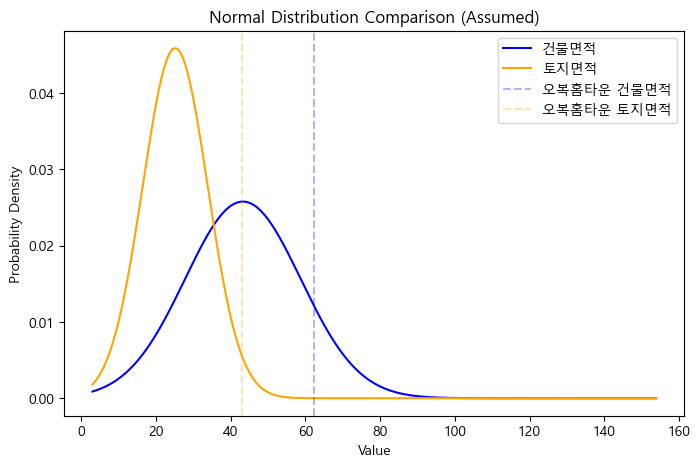

In [30]:
## 표준화 하기 전 건물 면적과 토지 면적
## 지금 이 코드는 이해하지 않아도 됩니다! 복붙해서 그림만 봐주세요

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data_A = multiplex_house_df_cleaned['건물면적']
data_B = multiplex_house_df_cleaned['토지면적']


# 두 변수의 평균과 표준편차
mu_A, sigma_A = np.mean(data_A), np.std(data_A)
mu_B, sigma_B = np.mean(data_B), np.std(data_B)

# x 범위 (두 분포를 모두 포함하도록)
x = np.linspace(
    min(min(data_A),min(data_B)),
    max(max(data_A),max(data_B)),
    500
)

# PDF 계산
pdf_A = norm.pdf(x, mu_A, sigma_A)
pdf_B = norm.pdf(x, mu_B, sigma_B)

# 시각화
plt.figure(figsize=(8,5))
plt.plot(x, pdf_A, label="건물면적",color ='blue')
plt.plot(x, pdf_B, label="토지면적",color ='orange')

plt.axvline(x=target['건물면적'].values,linestyle = "--", alpha=0.3, label="오복홈타운 건물면적",color ='blue')
plt.axvline(x=target['토지면적'].values,linestyle = "--", alpha=0.3, label="오복홈타운 토지면적",color='orange')


plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.title("Normal Distribution Comparison (Assumed)") #정규분포비교(가정된)
plt.legend()
plt.show()

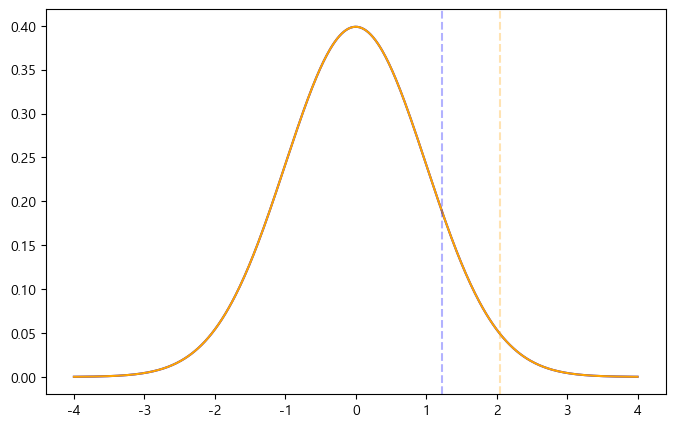

In [ ]:
## 표준화 후
## 지금 이 코드는 이해하지 않아도 됩니다! 복붙해서 그림만 봐주세요

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data_A = multiplex_house_df_cleaned['건물면적_표준화']
data_B = multiplex_house_df_cleaned['토지면적_표준화']
# 두 변수의 평균과 표준편차
mu_A, sigma_A = 0,1
mu_B, sigma_B = 0,1

# x 범위 (두 분포를 모두 포함하도록)
x = np.linspace(
    -4,4,500
)

# PDF 계산
pdf_A = norm.pdf(x, mu_A, sigma_A)
pdf_B = norm.pdf(x, mu_B, sigma_B)

# 시각화
plt.figure(figsize=(8,5))
plt.plot(x, pdf_A, label="건물면적",color ='blue')
plt.plot(x, pdf_B, label="토지면적",color ='orange')

plt.axvline(x=target['건물면적_표준화'].values,linestyle = "--", alpha=0.3, label="오복홈타운 건물면적",color ='blue')
plt.axvline(x=target['토지면적_표준화'].values,linestyle = "--", alpha=0.3, label="오복홈타운 토지면적",color='orange')


- 연립다세대주택 중에서 오복홈타운의 건물 면적과 토지면적은 평균보다 높은가?  
  - 그렇다
- 만약 둘 다 평균보다 높다고 나온다면, 오복홈타운의 건물면적과 토지면적 중 어떤 면적이 평균에서 더 멀리 떨어져있을까?
  - 토지면적이 더 멀리 떨어졌다. 표준화 점수를 비교해보니 토지면적의 표준화점수가 건물면적의 표준화 점수보다 높게 나왔다. 토지면적이 토지면적의 평균에서 떨어진 정도가 건물면적이 건물면적의 평균에서 떨어진 정도보다 더 크다는 걸 의미한다. 

## 신뢰구간 구하기

In [32]:
multiplex_house_df

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일
0,성원빌라(86-125),11380,은평구,10200,녹번동,4.00,연립다세대,16400,53.07,25.00,2024-10-14
1,팔팔빌라,11500,강서구,10300,화곡동,2.00,연립다세대,35000,39.24,27.00,2024-10-14
2,다솔시티하임,11560,영등포구,11100,당산동1가,5.00,연립다세대,30000,29.54,14.00,2024-10-14
9,진광,11500,강서구,10600,내발산동,1.00,연립다세대,15900,37.98,20.00,2024-10-14
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14
...,...,...,...,...,...,...,...,...,...,...,...
77516,세종에버그린(101동),11215,광진구,10700,화양동,8.00,연립다세대,30000,27.55,9.88,2023-01-24
77517,금석연립(170-33),11530,구로구,10700,개봉동,2.00,연립다세대,9740,53.61,124.00,2022-07-08
77518,금석연립(170-33),11530,구로구,10700,개봉동,1.00,연립다세대,9190,53.61,124.00,2022-07-08
77519,금석연립(170-33),11530,구로구,10700,개봉동,1.00,연립다세대,9190,53.61,124.00,2022-07-08


지금 우리가 알고 싶은 건 서울에 있는 모든 연립 다세대 주택의 물건금액 평균을 알아내는 것이다. <br>
하지만 우리는 약 2만개의 데이터만 가지고 있다. <br>
이 데이터를 가지고, 연립 다세대 주택의 물건 금액 평균을 추정해보자. 

우선 건물명, 자치구, 법정동, 층이 일치하는 데이터는 계약일이 가장 최근인 데이터만 남긴다. 

In [ ]:
# 같은 매물 데이터는 중복 제거
multiplex_house_only_df = multiplex_house_df.sort_values(['건물명','자치구코드','법정동코드','층','계약일']).drop_duplicates(subset=['건물명','자치구코드','법정동코드','층'],keep='last')

# 같은 건물·층끼리 묶이게 정렬, 그 안에서 계약일 순서대로 정렬 (기본값 = 오름차순)
# subset의 4개의 컬럼이 같으면 중복으로 간주!
# keep = 'last' 계약일 오름차순으로 정렬했으니, 그 중 가장 마지막 값(최신계약)만 남긴다.

In [ ]:
multiplex_house_only_df
# 4000개 정도의 행이 사라진 것 확인할 수 있음. 21183 -> 17469

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일
63288,(1-10),11410,서대문구,11700,연희동,3.00,연립다세대,27500,57.66,18.00,2024-03-08
53314,(1-109),11170,용산구,10200,용산동2가,3.00,연립다세대,52000,72.95,73.95,2024-04-13
74777,(1-12),11305,강북구,10300,수유동,5.00,연립다세대,49500,63.82,44.35,2024-01-07
35213,(1-1382),11170,용산구,10200,용산동2가,1.00,연립다세대,30000,30.79,24.00,2024-06-15
69068,(1-155),11200,성동구,10900,금호동1가,-1.00,연립다세대,21200,58.32,18.51,2024-02-07
...,...,...,...,...,...,...,...,...,...,...,...
34419,힐하우스(150-143),11215,광진구,10100,중곡동,5.00,연립다세대,21500,41.96,15.00,2024-06-17
15082,힐하우스(200-413),11440,마포구,12500,성산동,2.00,연립다세대,28000,34.45,21.00,2024-08-05
7653,힐하우스(200-413),11440,마포구,12500,성산동,4.00,연립다세대,45000,41.60,25.00,2024-08-27
3454,힐하우스(377-12),11500,강서구,10300,화곡동,4.00,연립다세대,20500,29.96,14.00,2024-09-11


In [ ]:
sample_data = multiplex_house_only_df['물건금액']

n = len(sample_data)
print(f"표본개수: {n}")

sample_mean = np.mean(sample_data)
print(f"표본평균: {sample_mean}")

s = np.std(sample_data, ddof = 1)
print(f"표본표준편차: {s}")

se = s/np.sqrt(n)
print(f"표본오차 근사값: {se}")

confidence_interval = stats.t.interval(confidence = 0.3, df = n-1, loc = sample_mean, scale = se)
print(f"신뢰구간: {confidence_interval}")
# 신뢰도를 낮추면 구간이 줄어듦. 왜냐? 덜 봐도 되니까.
# 신뢰도가 높을수록 정확해야하기 떄문에 범위 느는거.

표본개수: 17469
표본평균: 35134.07561966913
표본표준편차: 31173.267292549852
표본오차 근사값: 235.85674516830173
신뢰구간: (np.float64(35043.193694815316), np.float64(35224.95754452294))


95% 신뢰수준에서 서울 연립 다세대 주택의 물건금액 평균은 34,671만원에서 35,596만원 사이에 있다. 